In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

In [2]:
nav = pd.read_csv("../data/processed/clean_nav.csv")
aum = pd.read_csv("../data/processed/clean_aum.csv")
sip = pd.read_csv("../data/processed/clean_sip_inflows.csv")
category = pd.read_csv("../data/processed/clean_category_inflows.csv")
folio = pd.read_csv("../data/processed/clean_folio_count.csv")
performance = pd.read_csv("../data/processed/clean_performance.csv")
transactions = pd.read_csv("../data/processed/clean_transactions.csv")
holdings = pd.read_csv("../data/processed/clean_holdings.csv")
benchmark = pd.read_csv("../data/processed/clean_benchmark.csv")
fund = pd.read_csv("../data/processed/clean_fund_master.csv")

In [3]:
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Transactions:", transactions.shape)
print("Fund Master:", fund.shape)

NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Transactions: (32778, 13)
Fund Master: (40, 15)


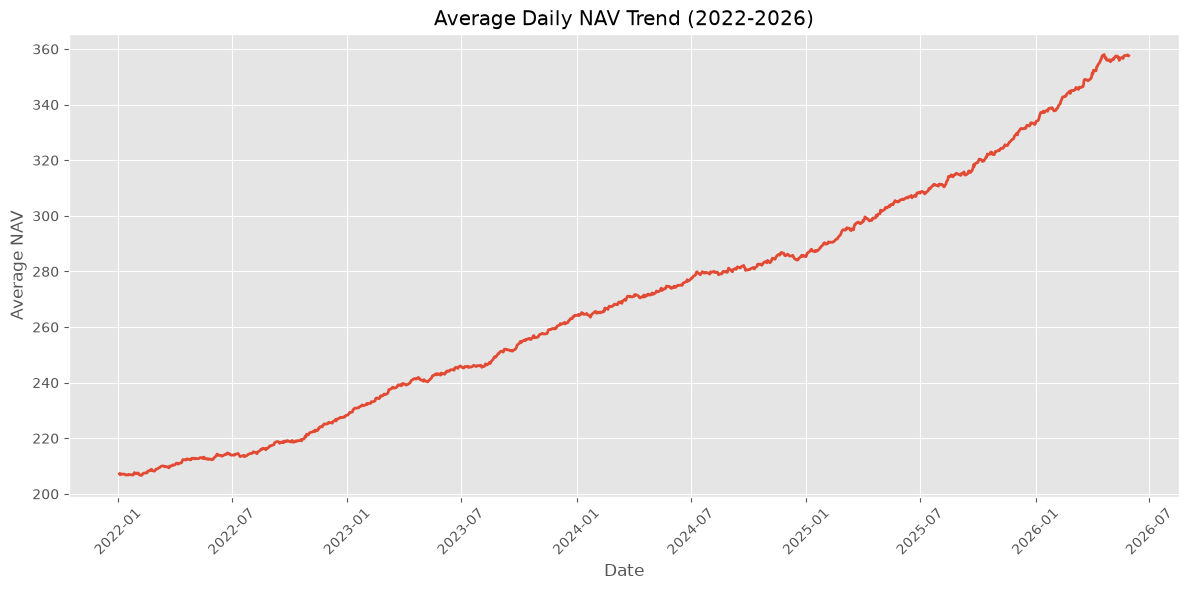

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

daily_nav = nav.groupby("date")["nav"].mean().reset_index()

plt.figure(figsize=(12,6))
plt.plot(daily_nav["date"], daily_nav["nav"], linewidth=2)
plt.title("Average Daily NAV Trend (2022-2026)")
plt.xlabel("Date")
plt.ylabel("Average NAV")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

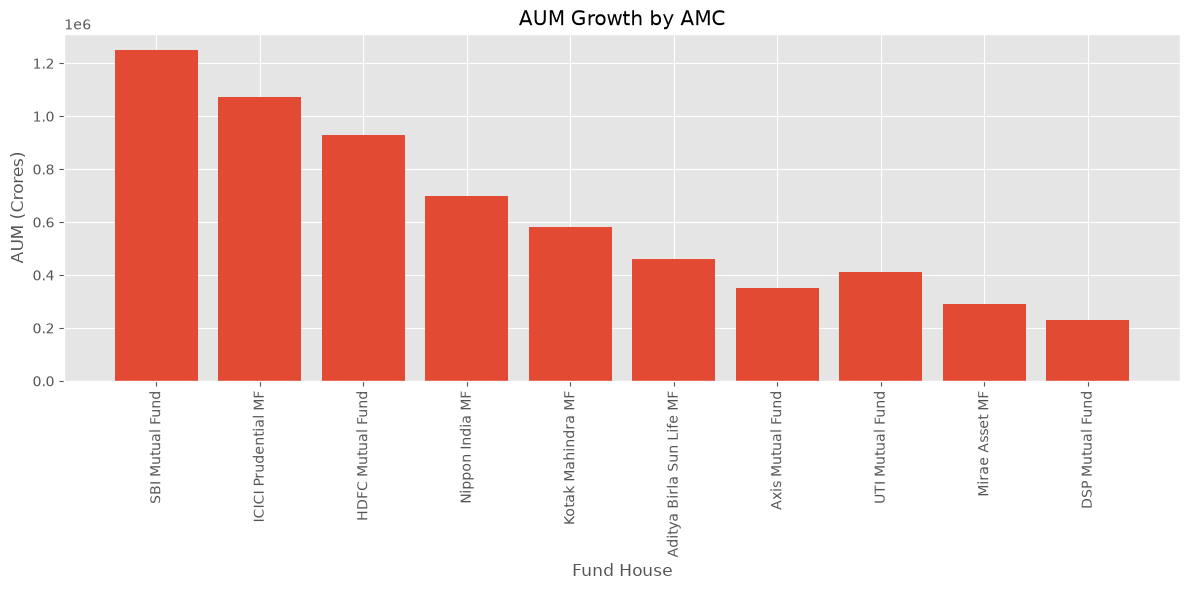

In [5]:
plt.figure(figsize=(12,6))

plt.bar(aum["fund_house"], aum["aum_crore"])

plt.title("AUM Growth by AMC")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crores)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

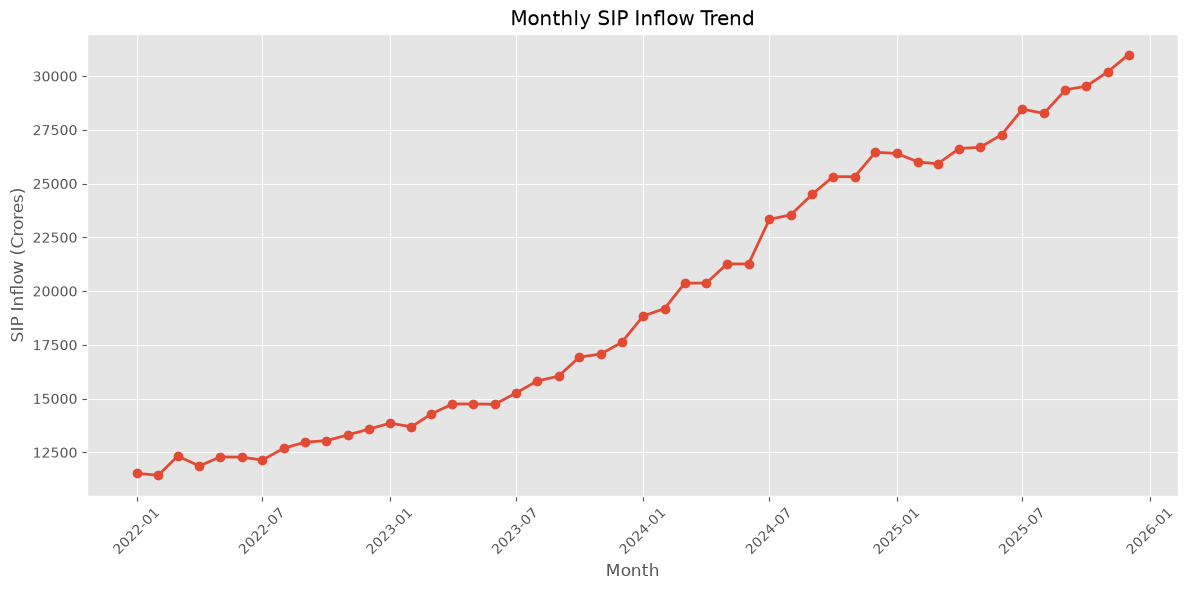

In [6]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,6))

plt.plot(sip["month"], sip["sip_inflow_crore"],
         marker="o", linewidth=2)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crores)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

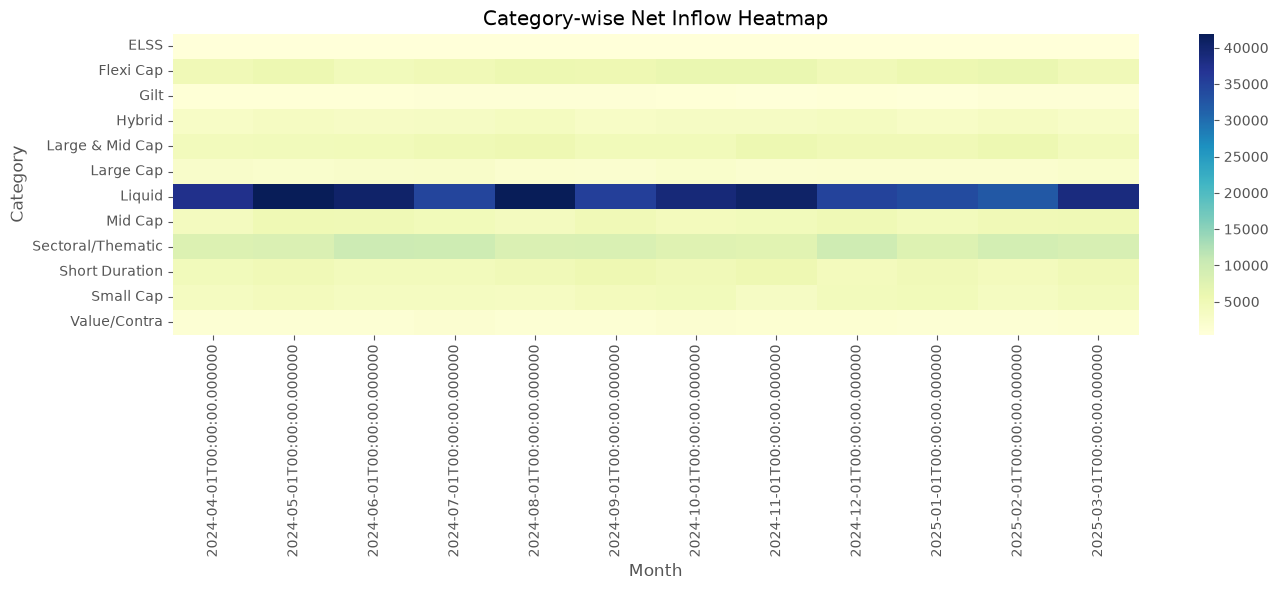

In [7]:
category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap="YlGnBu")

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [9]:
investor = pd.read_csv("../data/processed/clean_folio_count.csv")

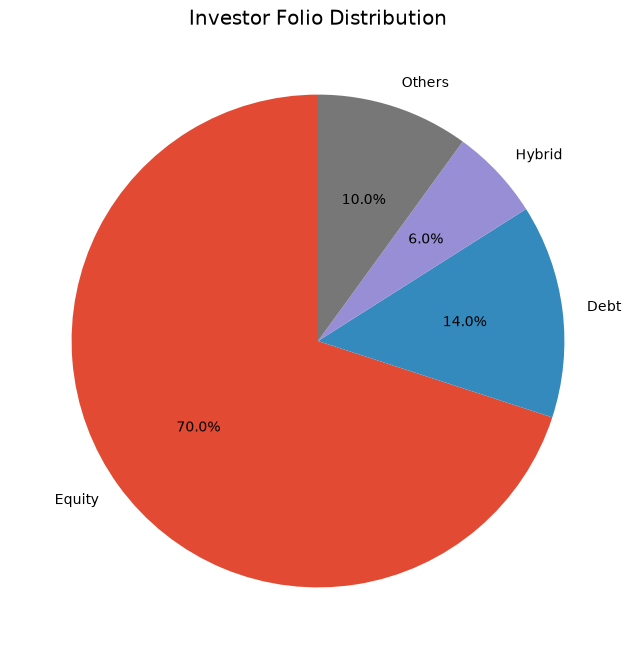

In [10]:
plt.figure(figsize=(8,8))

values = [
    investor["equity_folios_crore"].iloc[-1],
    investor["debt_folios_crore"].iloc[-1],
    investor["hybrid_folios_crore"].iloc[-1],
    investor["others_folios_crore"].iloc[-1]
]

labels = ["Equity", "Debt", "Hybrid", "Others"]

plt.pie(values, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Investor Folio Distribution")
plt.show()

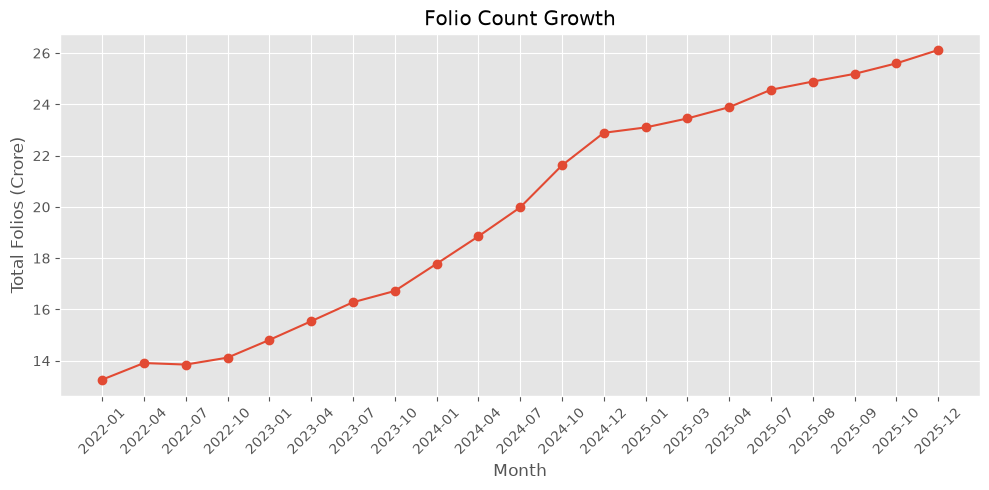

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    investor["month"],
    investor["total_folios_crore"],
    marker="o"
)

plt.title("Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

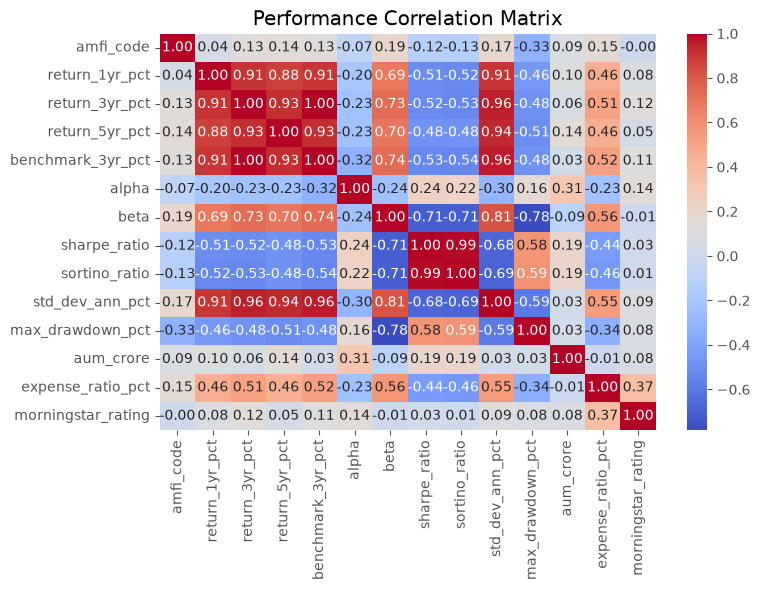

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = performance.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Performance Correlation Matrix")
plt.tight_layout()
plt.show()

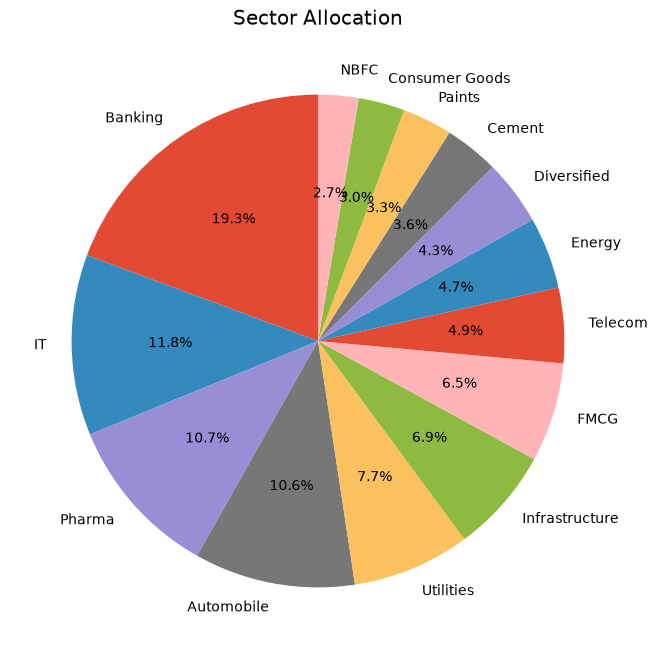

In [ ]:
import matplotlib.pyplot as plt

sector_data = holdings.groupby("sector")["market_value_cr"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,8))
plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sector Allocation")
plt.show()

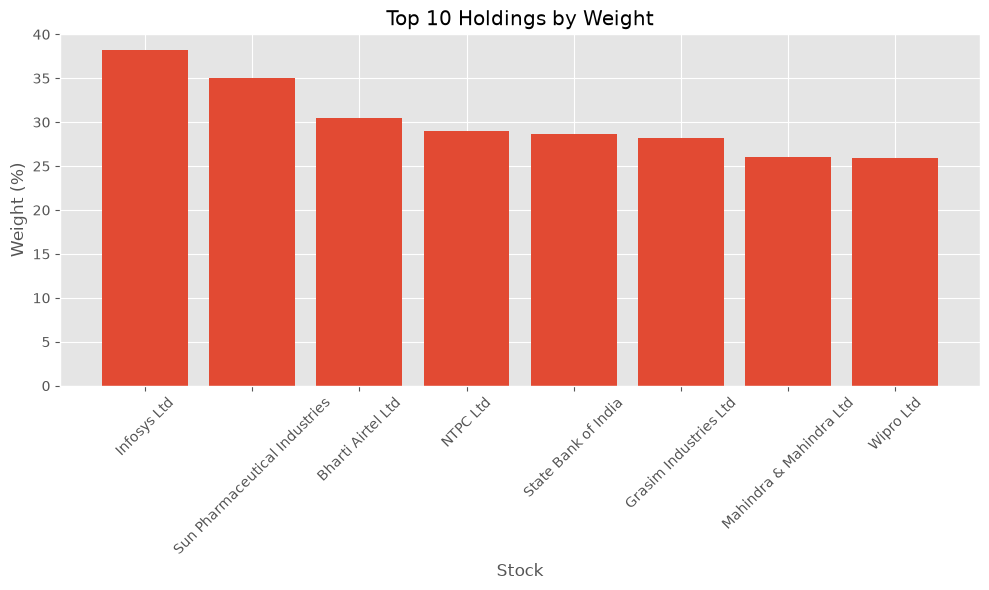

In [ ]:
import matplotlib.pyplot as plt

top10 = holdings.sort_values("weight_pct", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10["stock_name"], top10["weight_pct"])

plt.title("Top 10 Holdings by Weight")
plt.xlabel("Stock")
plt.ylabel("Weight (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Key EDA Findings


## NAV Trend

The NAV of mutual funds generally increased over the years. Although there were a few ups and downs, the overall trend shows steady growth from 2022 to 2025.

## AUM Analysis

Among all fund houses, SBI Mutual Fund had the highest AUM. This indicates that it manages a larger amount of investor money than most other fund houses.

## SIP Inflow

The monthly SIP inflows kept increasing during the analysis period. This suggests that more investors are choosing SIPs as a preferred investment method.

## Category-wise Inflows

Equity funds attracted higher inflows compared to most other categories. This shows that investors are more interested in equity-based investments for long-term returns.

## Investor Folios

Most investor folios belong to the equity category, while debt and hybrid funds have a comparatively smaller share.

## Folio Growth

The total number of investor folios increased every year. This reflects the growing popularity of mutual funds among investors.

## Correlation Analysis

The correlation matrix shows that some performance measures are closely related, while others are weakly related. This helps in understanding how different fund performance metrics move together.

## Sector Allocation

The portfolio is spread across different sectors such as Financial Services, IT, Pharma and others. This indicates that the investments are reasonably diversified.

## Top Holdings

A few stocks have a much higher portfolio weight than the others. These holdings are likely to have a greater impact on the fund’s overall performance.

## Overall Conclusion

Based on the EDA, the mutual fund industry shows positive growth in terms of NAV, AUM, SIP investments and investor participation. Overall, the data suggests a healthy and expanding mutual fund market.